# Battery Trading with Reinforcement Learning

This case study develops the same battery-trading problem in four layers:

1. **Markov Decision Process (MDP)** formulation  
2. **Tabular Q-learning**  
3. **Deep Q-Network (DQN)**  
4. **Evaluation against simple baselines**

The goal is to build a transparent engineering example showing exactly where reinforcement learning enters the problem.


## 1. What data do we need?

A minimal historical data table needs one row per time step.

| Column | Meaning | Required? |
|---|---|---|
| `timestamp` | Time of observation | Yes |
| `price` | Electricity price, e.g. EUR/MWh | Yes |
| `hour` | Hour of day | Can be derived |
| `day_of_week` | Weekday pattern | Can be derived |
| `load_forecast` | Demand forecast | Optional |
| `renewable_forecast` | Wind/solar forecast | Optional |
| `imbalance_price` | Balancing-market price | Optional |
| `temperature` | Weather-related demand signal | Optional |

Battery specifications are also required:

- energy capacity in MWh,
- maximum charge/discharge power in MW,
- charging and discharging efficiency,
- initial state of charge,
- minimum and maximum state of charge,
- optional degradation cost.

For this tutorial, we generate synthetic hourly prices so that the notebook runs without an external dataset.


In [1]:
from __future__ import annotations

import math
import random
from collections import deque
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2. Generate a synthetic electricity-price dataset

The generated series contains a daily price cycle, a weekly effect, random volatility, and occasional price spikes. Replace this cell later with real market data while keeping the rest of the notebook almost unchanged.


In [2]:
def generate_price_data(n_days: int = 240, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n_hours = n_days * 24
    timestamp = pd.date_range("2025-01-01", periods=n_hours, freq="h")

    hour = timestamp.hour.to_numpy()
    day_of_week = timestamp.dayofweek.to_numpy()

    daily_cycle = (
        18 * np.sin(2 * np.pi * (hour - 7) / 24)
        + 10 * np.sin(4 * np.pi * (hour - 16) / 24)
    )
    weekend_effect = np.where(day_of_week >= 5, -8.0, 0.0)
    regime = 8 * np.sin(2 * np.pi * np.arange(n_hours) / (24 * 30))
    noise = rng.normal(0, 7, size=n_hours)

    spikes = np.zeros(n_hours)
    spike_idx = rng.choice(n_hours, size=max(1, n_hours // 120), replace=False)
    spikes[spike_idx] = rng.choice([50, 80, -30], size=len(spike_idx), p=[0.5, 0.3, 0.2])

    price = 55 + daily_cycle + weekend_effect + regime + noise + spikes
    price = np.clip(price, -40, 180)

    return pd.DataFrame({
        "timestamp": timestamp,
        "price": price,
        "hour": hour,
        "day_of_week": day_of_week,
    })

df = generate_price_data()
df.head()


,timestamp,price,hour,day_of_week
0,2025-01-01 00:00:00,31.086101,0,2
1,2025-01-01 01:00:00,19.789924,1,2
2,2025-01-01 02:00:00,34.345859,2,2
3,2025-01-01 03:00:00,41.204911,3,2
4,2025-01-01 04:00:00,28.894028,4,2


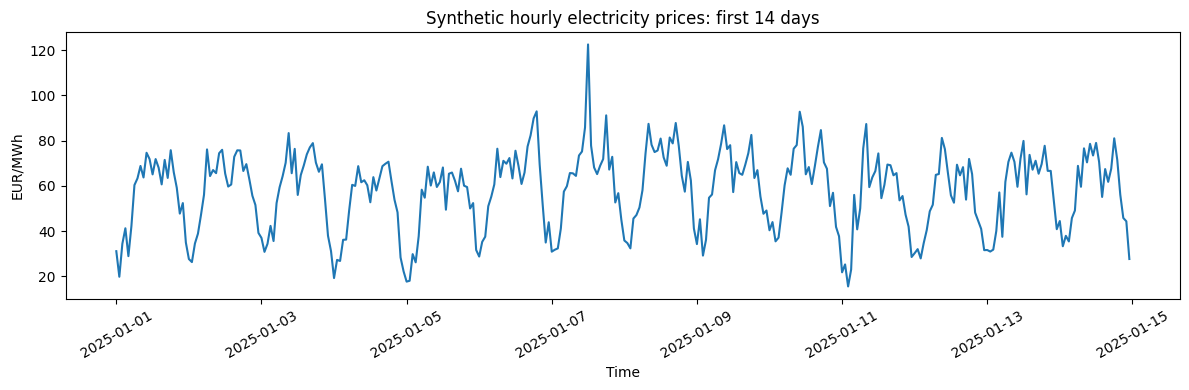

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
sample = df.iloc[: 24 * 14]
ax.plot(sample["timestamp"], sample["price"])
ax.set_title("Synthetic hourly electricity prices: first 14 days")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# 3. Markov Decision Process formulation

An MDP is defined by state, action, transition, reward, and discount factor.

## State

\[
s_t=(\text{state of charge},\ \text{price},\ \text{hour})
\]

## Actions

\[
a_t \in \{-1,0,+1\}
\]

- discharge,
- idle,
- charge.

## Reward

\[
r_t=p_tE_{\mathrm{sold}}-p_tE_{\mathrm{bought}}-c_{\mathrm{deg}}E_{\mathrm{throughput}}
\]

## Transition

\[
SOC_{t+1}=SOC_t+\eta_cE_{\mathrm{charge}}-\frac{E_{\mathrm{discharge}}}{\eta_d}
\]

The essential RL feature is that an action changes the state available for future decisions.


In [ ]:
@dataclass
class BatteryConfig:
    capacity_mwh: float = 10.0
    max_power_mw: float = 2.0
    charge_efficiency: float = 0.95
    discharge_efficiency: float = 0.95
    min_soc_mwh: float = 0.0
    max_soc_mwh: float = 10.0
    initial_soc_mwh: float = 5.0
    degradation_cost_eur_per_mwh: float = 2.0
    episode_hours: int = 24 * 7


class BatteryTradingEnv:
    """Lightweight environment without a Gym dependency.

    Observation: [soc_fraction, normalized_price, sin(hour), cos(hour)]
    Actions: 0=discharge, 1=idle, 2=charge
    """

    def __init__(self, data: pd.DataFrame, config: BatteryConfig | None = None,
                 random_start: bool = True, seed: int = 42) -> None:
        self.data = data.reset_index(drop=True).copy()
        self.config = config or BatteryConfig()
        self.random_start = random_start
        self.rng = np.random.default_rng(seed)
        self.price_mean = float(self.data["price"].mean())
        self.price_std = float(self.data["price"].std() + 1e-8)
        self.start_index = self.index = self.end_index = 0
        self.soc = self.config.initial_soc_mwh
        self.total_profit = 0.0

    def reset(self, start_index: int | None = None) -> np.ndarray:
        max_start = len(self.data) - self.config.episode_hours - 1
        if max_start < 0:
            raise ValueError("The dataset is shorter than one episode.")
        if start_index is not None:
            self.start_index = int(np.clip(start_index, 0, max_start))
        elif self.random_start:
            self.start_index = int(self.rng.integers(0, max_start + 1))
        else:
            self.start_index = 0
        self.index = self.start_index
        self.end_index = self.start_index + self.config.episode_hours
        self.soc = self.config.initial_soc_mwh
        self.total_profit = 0.0
        return self._observation()

    def _observation(self) -> np.ndarray:
        row = self.data.iloc[self.index]
        hour = int(row["hour"])
        return np.array([
            self.soc / self.config.capacity_mwh,
            (float(row["price"]) - self.price_mean) / self.price_std,
            math.sin(2 * math.pi * hour / 24),
            math.cos(2 * math.pi * hour / 24),
        ], dtype=np.float32)

    def step(self, action: int):
        if action not in (0, 1, 2):
            raise ValueError("Action must be 0, 1, or 2.")

        price = float(self.data.iloc[self.index]["price"])
        cfg = self.config
        bought_from_grid = sold_to_grid = battery_throughput = 0.0

        if action == 2:  # charge
            room = cfg.max_soc_mwh - self.soc
            energy_into_battery = min(cfg.max_power_mw * cfg.charge_efficiency, room)
            bought_from_grid = energy_into_battery / cfg.charge_efficiency
            self.soc += energy_into_battery
            battery_throughput = energy_into_battery
        elif action == 0:  # discharge
            available = self.soc - cfg.min_soc_mwh
            energy_from_battery = min(cfg.max_power_mw / cfg.discharge_efficiency, available)
            sold_to_grid = energy_from_battery * cfg.discharge_efficiency
            self.soc -= energy_from_battery
            battery_throughput = energy_from_battery

        reward = (price * sold_to_grid - price * bought_from_grid
                  - cfg.degradation_cost_eur_per_mwh * battery_throughput)
        self.total_profit += reward
        self.index += 1
        done = self.index >= self.end_index
        next_obs = np.zeros(4, dtype=np.float32) if done else self._observation()
        info = {
            "price": price,
            "soc_mwh": self.soc,
            "bought_mwh": bought_from_grid,
            "sold_mwh": sold_to_grid,
            "profit": reward,
            "total_profit": self.total_profit,
        }
        return next_obs, float(reward), done, info


## 4. Baseline strategies

Always compare RL with simple policies. We use an idle policy and a threshold policy that charges at low prices and discharges at high prices.


In [ ]:
def run_policy(env: BatteryTradingEnv, policy_fn, start_index: int = 0):
    obs = env.reset(start_index=start_index)
    records = []
    done = False
    while not done:
        action = int(policy_fn(obs, env))
        next_obs, reward, done, info = env.step(action)
        records.append({"index": env.index - 1, "action": action, "reward": reward, **info})
        obs = next_obs
    return pd.DataFrame(records)


def idle_policy(obs, env):
    return 1


def make_threshold_policy(low_price: float, high_price: float):
    def policy(obs, env):
        price = float(env.data.iloc[env.index]["price"])
        if price <= low_price:
            return 2
        if price >= high_price:
            return 0
        return 1
    return policy


# 5. Tabular Q-learning

Q-learning stores an action value for every discrete state-action pair:

\[
Q(s_t,a_t)\leftarrow Q(s_t,a_t)+\alpha\left[r_t+\gamma\max_aQ(s_{t+1},a)-Q(s_t,a_t)\right]
\]

Because state of charge and price are continuous, we discretise them into bins.


In [ ]:
class StateDiscretizer:
    def __init__(self, price_values: np.ndarray, n_soc_bins: int = 11,
                 n_price_bins: int = 12) -> None:
        self.n_soc_bins = n_soc_bins
        self.n_price_bins = n_price_bins
        quantiles = np.linspace(0, 1, n_price_bins + 1)[1:-1]
        self.price_edges = np.quantile(price_values, quantiles)

    def encode(self, env: BatteryTradingEnv):
        price = float(env.data.iloc[env.index]["price"])
        hour = int(env.data.iloc[env.index]["hour"])
        soc_fraction = env.soc / env.config.capacity_mwh
        soc_bin = min(int(soc_fraction * self.n_soc_bins), self.n_soc_bins - 1)
        price_bin = int(np.digitize(price, self.price_edges))
        return soc_bin, price_bin, hour


In [ ]:
def train_tabular_q_learning(train_data: pd.DataFrame, episodes: int = 3000,
                             alpha: float = 0.12, gamma: float = 0.98,
                             epsilon_start: float = 1.0,
                             epsilon_end: float = 0.05, seed: int = 42):
    env = BatteryTradingEnv(train_data, BatteryConfig(), random_start=True, seed=seed)
    discretizer = StateDiscretizer(train_data["price"].to_numpy())
    q_table = np.zeros((discretizer.n_soc_bins,
                        discretizer.n_price_bins, 24, 3), dtype=np.float64)
    rng = np.random.default_rng(seed)
    episode_rewards = []

    for episode in range(episodes):
        env.reset()
        state = discretizer.encode(env)
        done = False
        total_reward = 0.0
        progress = episode / max(episodes - 1, 1)
        epsilon = epsilon_start * (1 - progress) + epsilon_end * progress

        while not done:
            action = int(rng.integers(0, 3)) if rng.random() < epsilon else int(np.argmax(q_table[state]))
            _, reward, done, _ = env.step(action)
            total_reward += reward
            if done:
                td_target = reward
            else:
                next_state = discretizer.encode(env)
                td_target = reward + gamma * np.max(q_table[next_state])
            td_error = td_target - q_table[state + (action,)]
            q_table[state + (action,)] += alpha * td_error
            if not done:
                state = next_state
        episode_rewards.append(total_reward)

    return q_table, discretizer, np.asarray(episode_rewards)

split = int(len(df) * 0.8)
train_df = df.iloc[:split].reset_index(drop=True)
test_df = df.iloc[split:].reset_index(drop=True)

q_table, discretizer, q_rewards = train_tabular_q_learning(train_df)
print("Q-table shape:", q_table.shape)
print("Mean reward in final 200 episodes:", q_rewards[-200:].mean())


In [ ]:
rolling = pd.Series(q_rewards).rolling(100).mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolling)
ax.set_title("Tabular Q-learning training reward")
ax.set_xlabel("Episode")
ax.set_ylabel("100-episode rolling reward")
plt.tight_layout()
plt.show()


In [ ]:
def q_learning_policy(obs, env):
    state = discretizer.encode(env)
    return int(np.argmax(q_table[state]))

q_result = run_policy(BatteryTradingEnv(test_df, random_start=False),
                      q_learning_policy, start_index=0)
q_result[["price", "soc_mwh", "action", "profit"]].head()


# 6. Deep Q-Network

A DQN approximates the action-value function with a neural network:

\[
Q(s,a;\theta)
\]

Inputs are state of charge, normalised price, and cyclical time features. Outputs are the estimated values of discharge, idle, and charge.


In [ ]:
try:
    import torch
    from torch import nn
    from torch.optim import Adam
except ImportError as exc:
    raise ImportError("PyTorch is required for the DQN section.") from exc

torch.manual_seed(SEED)


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity: int = 100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((np.asarray(state, dtype=np.float32), int(action),
                            float(reward), np.asarray(next_state, dtype=np.float32),
                            bool(done)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.stack(states), np.asarray(actions, dtype=np.int64),
                np.asarray(rewards, dtype=np.float32), np.stack(next_states),
                np.asarray(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, state_dim: int = 4, action_dim: int = 3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.network(x)


In [ ]:
def train_dqn(train_data: pd.DataFrame, episodes: int = 1200,
              gamma: float = 0.98, learning_rate: float = 1e-3,
              batch_size: int = 128, replay_capacity: int = 100_000,
              warmup_steps: int = 1000, target_update_steps: int = 500,
              epsilon_start: float = 1.0, epsilon_end: float = 0.05,
              epsilon_decay_steps: int = 50_000, seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = BatteryTradingEnv(train_data, random_start=True, seed=seed)
    policy_net = DQN().to(device)
    target_net = DQN().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = Adam(policy_net.parameters(), lr=learning_rate)
    loss_fn = nn.SmoothL1Loss()
    replay = ReplayBuffer(replay_capacity)
    total_steps = 0
    episode_rewards, losses = [], []

    for episode in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-total_steps / epsilon_decay_steps)
            if random.random() < epsilon:
                action = random.randrange(3)
            else:
                with torch.no_grad():
                    state_tensor = torch.tensor(state, dtype=torch.float32,
                                                device=device).unsqueeze(0)
                    action = int(policy_net(state_tensor).argmax(dim=1).item())

            next_state, reward, done, _ = env.step(action)
            replay.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            total_steps += 1

            if len(replay) >= max(batch_size, warmup_steps):
                states, actions, rewards, next_states, dones = replay.sample(batch_size)
                states_t = torch.tensor(states, dtype=torch.float32, device=device)
                actions_t = torch.tensor(actions, dtype=torch.long, device=device)
                rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device)
                next_states_t = torch.tensor(next_states, dtype=torch.float32, device=device)
                dones_t = torch.tensor(dones, dtype=torch.float32, device=device)

                current_q = policy_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(next_states_t).max(dim=1).values
                    target_q = rewards_t + gamma * (1.0 - dones_t) * next_q

                loss = loss_fn(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
                optimizer.step()
                losses.append(float(loss.item()))

            if total_steps % target_update_steps == 0:
                target_net.load_state_dict(policy_net.state_dict())

        episode_rewards.append(total_reward)

    return policy_net, np.asarray(episode_rewards), np.asarray(losses), device


dqn_model, dqn_rewards, dqn_losses, device = train_dqn(train_df)
print("Device:", device)
print("Mean reward in final 100 episodes:", dqn_rewards[-100:].mean())


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pd.Series(dqn_rewards).rolling(50).mean())
ax.set_title("DQN training reward")
ax.set_xlabel("Episode")
ax.set_ylabel("50-episode rolling reward")
plt.tight_layout()
plt.show()


In [ ]:
def make_dqn_policy(model, device):
    model.eval()
    def policy(obs, env):
        with torch.no_grad():
            state_tensor = torch.tensor(obs, dtype=torch.float32,
                                        device=device).unsqueeze(0)
            return int(model(state_tensor).argmax(dim=1).item())
    return policy


dqn_policy = make_dqn_policy(dqn_model, device)
dqn_result = run_policy(BatteryTradingEnv(test_df, random_start=False),
                        dqn_policy, start_index=0)
dqn_result[["price", "soc_mwh", "action", "profit"]].head()


# 7. Evaluation on unseen data

We compare total profit, energy bought, energy sold, and active trading hours. A serious study should repeat this evaluation over many non-overlapping windows.


In [ ]:
low_threshold = float(train_df["price"].quantile(0.30))
high_threshold = float(train_df["price"].quantile(0.70))

evaluation_env = BatteryTradingEnv(test_df, random_start=False)
idle_result = run_policy(evaluation_env, idle_policy, start_index=0)
threshold_result = run_policy(evaluation_env,
                              make_threshold_policy(low_threshold, high_threshold),
                              start_index=0)

def summarize(name: str, result: pd.DataFrame) -> dict:
    return {
        "policy": name,
        "profit_eur": result["profit"].sum(),
        "bought_mwh": result["bought_mwh"].sum(),
        "sold_mwh": result["sold_mwh"].sum(),
        "active_hours": int((result["action"] != 1).sum()),
    }

summary = pd.DataFrame([
    summarize("Idle", idle_result),
    summarize("Threshold", threshold_result),
    summarize("Tabular Q-learning", q_result),
    summarize("DQN", dqn_result),
]).sort_values("profit_eur", ascending=False)
summary


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary["policy"], summary["profit_eur"])
ax.set_title("Test-period profit by strategy")
ax.set_ylabel("Profit (EUR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
plot_df = dqn_result.copy()
plot_df["time"] = test_df.iloc[plot_df["index"]]["timestamp"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["time"], plot_df["price"])
ax.set_title("DQN trading window: electricity price")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["time"], plot_df["soc_mwh"])
ax.set_title("DQN trading window: battery state of charge")
ax.set_ylabel("MWh")
ax.set_xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# 8. How this differs from Camp Chain

Both approaches use a feedback loop: propose or choose, evaluate, update, repeat.

## Camp Chain

- Candidate: model-parameter vector
- Evaluation: simulation error or objective value
- Output: one good parameter vector
- Typical classification: stochastic or adaptive numerical optimisation

## Battery RL

- Candidate: action selected in the current state
- Evaluation: immediate and future reward
- Output: a policy mapping many states to actions
- Typical classification: sequential decision-making under an MDP

Your optimisation background is directly relevant to exploration, objectives, convergence, and algorithm evaluation in RL.


# 9. Stronger portfolio extensions

Add real prices, balancing-market prices, weather and renewable forecasts, degradation linked to depth of discharge, terminal energy value, Double DQN, Dueling DQN, and a comparison with a perfect-foresight linear program.

A strong chapter title is:

> **From Mathematical Optimisation to Reinforcement Learning: A Battery-Trading Case Study**
